In [1]:
import sys
import os
current_dir = os.path.dirname(os.curdir)
parent_dir = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.append(parent_dir)
import torch
import system.units as units
import system.topology as topology
import system.box as box
import forces.twobody as twobody
import system.system as sys
from integrators.NVE import NVE
from integrators.NVT import NVT
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import itertools
from tqdm import trange
from utils import *
import freud
%matplotlib inline
from IPython.display import clear_output, display
device = "cuda"


╔═══════════════════════════════════════════════════╗
║                                                   ║
║  ██████╗   ██████╗    ██╗      ██████╗   ██╗  ██╗ ║
║ ██╔════╝  ██╔══██╗   ██╔██╗    ██╔══██╗  ██║ ██╔╝ ║
║ ╚█████╗   ██████╔╝  ██╔╝╚██╗   ██████╔╝  █████╔╝  ║
║  ╚═══██╗  ██╔═══╝  ██╔╝  ╚██╗  ██╔══██╗  ██╔═██╗  ║
║ ██████╔╝  ██║     ██╔╝    ╚██╗ ██║  ██║  ██║ ╚██╗ ║
║ ╚═════╝   ╚═╝     ╚═╝      ╚═╝ ╚═╝  ╚═╝  ╚═╝  ╚═╝ ║
║                                                   ║
║     Statistical Physics Autodiff Research Kit     ║
╚═══════════════════════════════════════════════════╝

          V(r)           ψ, φ              q
           │               │               │
           ○               ○               ○
         ╱ | ╲           ╱ | ╲           ╱ | ╲
        ○  ○  ○         ○  ○  ○         ○  ○  ○
         ╲ | ╱           ╲ | ╱           ╲ | ╱
           ○               ○               ○
           │               │               │
          g(r)             F         

In [2]:
arity_table = (
    ["mie"],
    [2]
)
top = topology.Topology(arity_table)
print(top)
for i in range(15**3):
    for j in range(i):
        top.add(2,"mie",(i,j))

b = box.Box([15.872443025792107,15.872443025792107,15.872443025792107],["p","p","p"])
print(b)

u = units.UnitSystem()
print(u)

n =  torch.nn.Parameter(torch.tensor(12.0)) 
sigma = torch.nn.Parameter(torch.tensor(1.0)) 
epsilon = torch.nn.Parameter(torch.tensor(1.0)) 

mie = twobody.Mie(n = n, sigma = sigma, epsilon = epsilon, label = "mie")

B = 8
pos = make_sc_lattice(a=1.05, nx=15, ny=15, nz=15, batch=B)  # (4, 20**3, 3)
N = len(pos[0])
pos = pos - pos.mean(dim=1, keepdim=True) + torch.tensor([[b.Lx, b.Ly, b.Lz]], device=device) / 2
mom = 0.59*torch.randn(B,N,3,device=device)
mass = torch.ones(N,device=device)
mass = mass.unsqueeze(dim=0).expand(B,N)

energy_dict = {"mie":mie}
S = sys.System(pos, mom, mass, top, b, energy_dict, u)
S.compile_force_fn()
print(S)

integrator = NVE(0.01)
print(integrator)

print(f"Density {(len(pos[0])/b.volume).item()}")

Topology(mie (arity 2))
Box(15.8724p, 15.8724p, 15.8724p)
UnitSystem(L=1 m/uL, E=1 J/uE, M=1 kg/um, kB=1 uE/K, Q=1 e/uQ)
System(Batches: 8, Atoms: 3375, Interactions: 1, Box: Box(15.8724p, 15.8724p, 15.8724p), Units: UnitSystem(L=1 m/uL, E=1 J/uE, M=1 kg/um, kB=1 uE/K, Q=1 e/uQ))
NVE(dt=0.01)
Density 0.8440000414848328


In [3]:
# def g_hist(x: torch.Tensor,
#            bins: int,
#            r_max: float,
#            sigma: float | torch.Tensor,
#            *,
#            chunk: int = 200_000) -> torch.Tensor:
#     w   = r_max / bins
#     c   = (torch.arange(bins, device=x.device, dtype=x.dtype) + 0.5) * w
#     sigma = torch.as_tensor(sigma, dtype=x.dtype, device=x.device)

#     counts = None
#     for s in range(0, x.numel(), chunk):
#         x_block = x[s:s+chunk]                       # (chunk,)
#         d = (x_block[:, None] - c[None, :]) / sigma  # (chunk, bins)
#         contrib = torch.exp(-0.5 * d**2)             # (chunk, bins)
#         contrib /= contrib.sum(dim=1, keepdim=True)  # normalize each row to 1
#         block_cnt = contrib.sum(dim=0)               # (bins,)
#         counts = block_cnt if counts is None else counts + block_cnt

#     return c, counts

import torch.utils.checkpoint as cp

def g_hist(x: torch.Tensor,
           bins: int,
           r_max: float,
           sigma: float | torch.Tensor,
           *,
           chunk: int = 200_000) -> torch.Tensor:
    
    w = r_max / bins
    c = (torch.arange(bins, device=x.device, dtype=x.dtype) + 0.5) * w
    sigma = torch.as_tensor(sigma, dtype=x.dtype, device=x.device)

    def block_fn(x_block):
        d = (x_block[:, None] - c[None, :]) / sigma  # (chunk, bins)
        contrib = torch.exp(-0.5 * d**2)             # (chunk, bins)
        return (contrib/contrib.sum(dim=1, keepdim=True)).sum(dim=0)  # normalize each row to 1 (bins,)

    counts = None
    for s in range(0, x.numel(), chunk):
        x_block = x[s:s+chunk]
        x_block.requires_grad_(x.requires_grad)  # match gradient tracking
        block_cnt = cp.checkpoint(block_fn, x_block) # magic function that I dont understand .... 
        counts = block_cnt if counts is None else counts + block_cnt

    return c, counts



def compute_rdf_from_conf(pos, box, A_idx, B_idx, *, nbins=200, smear=0.01, exclude_diag=False,chunk = 200_000):

    if smear <= 0:
        raise ValueError("Smearing needs to be non zero to be differentiable.")

    A_pos = pos[:,A_idx] # B, N_A, 3
    B_pos = pos[:,B_idx] # B, N_B, 3

    # r_ab = A_pos.unsqueeze(dim=-2) - B_pos.unsqueeze(dim=-3)  # B, N_A, N_B, 3

    if exclude_diag:
        i, j = torch.triu_indices(len(A_idx), len(A_idx), offset=1, device=A_pos.device)
        r_ab = torch.cat([A_pos[:, i] - A_pos[:, j], A_pos[:, j] - A_pos[:, i]], dim=1)
    else:
        r_ab = A_pos.unsqueeze(-2) - A_pos.unsqueeze(-3)  # (B, N, N, 3)
    
    # center atoms
    r_ab -= box.edges.unsqueeze(0).unsqueeze(0) * torch.round(r_ab / box.edges.unsqueeze(0).unsqueeze(0))

    # apply abs 
    r_ab = r_ab.norm(dim=-1)
    r_flat = r_ab.view(-1)

    # Cut rdf off at box_length/2
    r_max  = (box.edges.min(dim=-1).values / 2)
    r_flat = r_flat[r_flat < r_max]    
    
    dr     = r_max / nbins
    centers,counts = g_hist(r_flat, bins=nbins, r_max=r_max, sigma=smear,chunk=chunk)
        
    bin_edges  = torch.linspace(0.0, r_max, nbins + 1, device=r_flat.device)
    shell_vol  = (4/3) * math.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)
    
    N_A        = len(A_idx)                     # particles per frame
    N_B        = len(B_idx) 
    Btot       = S.pos.shape[0]                 # number of frames
    V          = box.volume
    
    # g_ab(r) = V / (N_A N_B) * ⟨delta(|r_i-r_j| - r)⟩ / shell_vol
    norm_pairs = N_A * N_B * Btot               # total A–B pairs sampled
    g_r        = counts * V / (norm_pairs * shell_vol)
    
    r_centers  = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return r_centers[r_centers < (r_max - 3*smear)], g_r[r_centers < (r_max - 3*smear)]

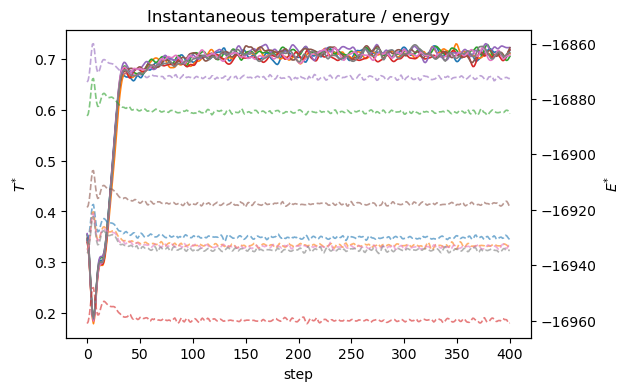

Equilibrating: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:27<00:00, 18.11it/s]


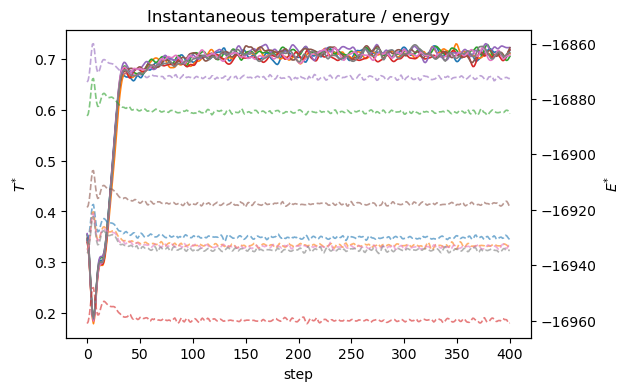

In [4]:
steps, eql_time, skip, bins = 2_000, 500, 50, 500

temperature = torch.empty((steps + eql_time, B), device=device)
total_energy = torch.empty((steps + eql_time, B), device=device)
rdfs        = torch.empty((steps // skip, bins), device=device)

plt.ion()                            

plot_skip  = 100                    
show_reps  = range(0, B, 1)          

fig, ax = plt.subplots(figsize=(6, 4))

ax_e = ax.twinx()             

lines_T, lines_E = [], []   
for j in show_reps:
    (lnT,) = ax.plot([], [], lw=1.2, label=f"rep {j}")       # temperature
    (lnE,) = ax_e.plot([], [], lw=1.2, ls="--", alpha=0.6)   # energy (dashed)
    lines_T.append(lnT); lines_E.append(lnE)
ax.set_xlabel("step")
ax.set_ylabel(r"$T^{*}$")
ax_e.set_ylabel(r"$E^{*}$")
ax.set_title("Instantaneous temperature / energy")

fig.canvas.draw()                    

def _refresh_plot(step):
    x = np.arange(step + 1)

    for lnT, lnE, j in zip(lines_T, lines_E, show_reps):
        lnT.set_data(x, temperature[:step + 1, j].cpu())
        lnE.set_data(x, total_energy[:step + 1, j].cpu()) 

    for a in (ax, ax_e):
        a.relim(); a.autoscale_view()

    clear_output(wait=True)   # nuke old image
    display(fig)              # show the updated one

# EQUILIBRATION
with torch.no_grad():
    for i in trange(eql_time, desc="Equilibrating"):
        temperature[i] = S.temperature()
        total_energy[i] = S.total_energy()
        integrator.step(S)
        S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

        if i % plot_skip == 0:
            _refresh_plot(i)

        S.reset_cache()

/users/1/sull1276/.conda/envs/spark/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/users/1/sull1276/.conda/envs/spark/lib/python3.10/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


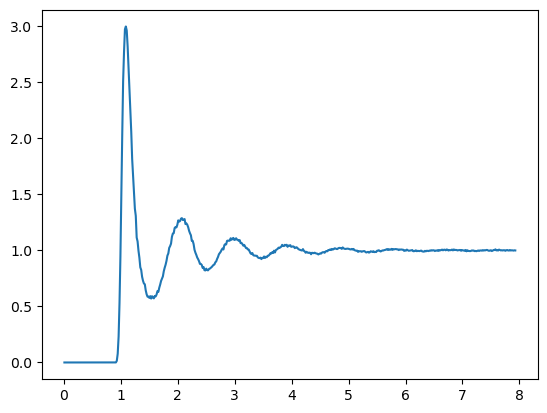

In [5]:
with torch.no_grad():
    r,target_rdf = compute_rdf_from_conf(S.pos,S.box, torch.arange(N),torch.arange(N),smear=0.001,nbins=bins,exclude_diag=True)
    plt.plot(r.detach().cpu(),target_rdf.detach().cpu())
    plt.show()

In [33]:
n =  torch.nn.Parameter(torch.tensor(15.0)) 
sigma = torch.nn.Parameter(torch.tensor(0.7)) 
epsilon = torch.nn.Parameter(torch.tensor(1.5)) 

mie = twobody.Mie(n = n, sigma = sigma, epsilon = epsilon, label = "mie")

B = 1
pos = make_sc_lattice(a=1.05, nx=15, ny=15, nz=15, batch=B)  # (4, 20**3, 3)
N = len(pos[0])
pos = pos - pos.mean(dim=1, keepdim=True) + torch.tensor([[b.Lx, b.Ly, b.Lz]], device=device) / 2
mom = 0.59*torch.randn(B,N,3,device=device)
mass = torch.ones(N,device=device)
mass = mass.unsqueeze(dim=0).expand(B,N)

energy_dict = {"mie":mie}
S = sys.System(pos, mom, mass, top, b, energy_dict, u)
S.compile_force_fn()
print(S)

integrator = NVE(0.005)
print(integrator)

print(f"Density {(len(pos[0])/b.volume).item()}")

System(Batches: 1, Atoms: 3375, Interactions: 1, Box: Box(15.8724p, 15.8724p, 15.8724p), Units: UnitSystem(L=1 m/uL, E=1 J/uE, M=1 kg/um, kB=1 uE/K, Q=1 e/uQ))
NVE(dt=0.005)
Density 0.8440000414848328


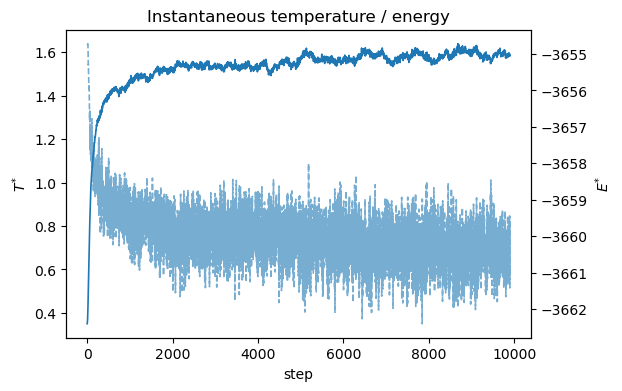

Equilibrating: 100%|███████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:15<00:00, 132.12it/s]


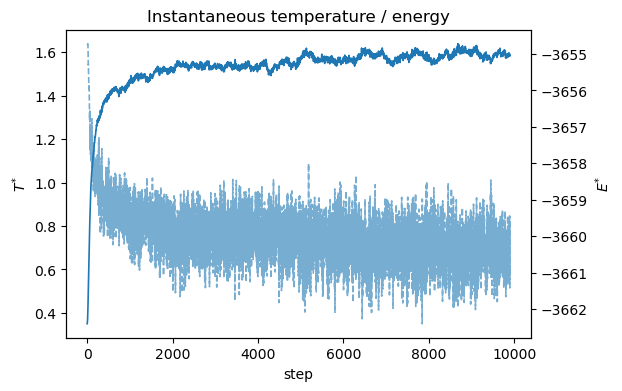

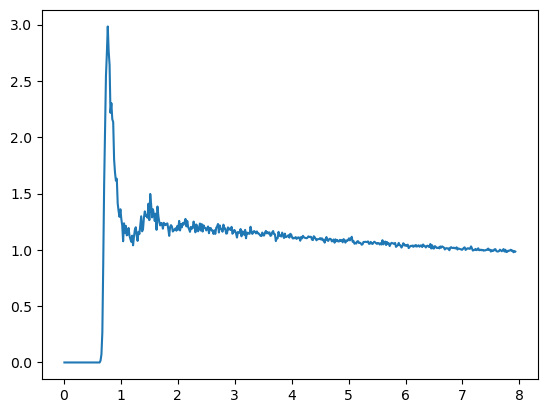

In [34]:
steps, eql_time, skip, bins = 2_000, 10000, 50, 500

temperature = torch.empty((steps + eql_time, B), device=device)
total_energy = torch.empty((steps + eql_time, B), device=device)
rdfs        = torch.empty((steps // skip, bins), device=device)

plt.ion()                            

plot_skip  = 100                    
show_reps  = range(0, B, 1)          

fig, ax = plt.subplots(figsize=(6, 4))

ax_e = ax.twinx()             

lines_T, lines_E = [], []   
for j in show_reps:
    (lnT,) = ax.plot([], [], lw=1.2, label=f"rep {j}")       # temperature
    (lnE,) = ax_e.plot([], [], lw=1.2, ls="--", alpha=0.6)   # energy (dashed)
    lines_T.append(lnT); lines_E.append(lnE)
ax.set_xlabel("step")
ax.set_ylabel(r"$T^{*}$")
ax_e.set_ylabel(r"$E^{*}$")
ax.set_title("Instantaneous temperature / energy")

fig.canvas.draw()                    

def _refresh_plot(step):
    x = np.arange(step + 1)

    for lnT, lnE, j in zip(lines_T, lines_E, show_reps):
        lnT.set_data(x, temperature[:step + 1, j].cpu())
        lnE.set_data(x, total_energy[:step + 1, j].cpu()) 

    for a in (ax, ax_e):
        a.relim(); a.autoscale_view()

    clear_output(wait=True)   # nuke old image
    display(fig)              # show the updated one

# EQUILIBRATION
with torch.no_grad():
    for i in trange(eql_time, desc="Equilibrating"):
        temperature[i] = S.temperature()
        total_energy[i] = S.total_energy()
        integrator.step(S)
        S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

        if i % plot_skip == 0:
            _refresh_plot(i)

        S.reset_cache()
    plt.show()
    
    r,rdf = compute_rdf_from_conf(S.pos,S.box, torch.arange(N),torch.arange(N),smear=0.001,nbins=bins,exclude_diag=True)
    plt.plot(r.detach().cpu(),rdf.detach().cpu())
    plt.show()

In [17]:
param_history = []
loss_history = []

  0%|                                                                                                                     | 0/500 [00:00<?, ?it/s]

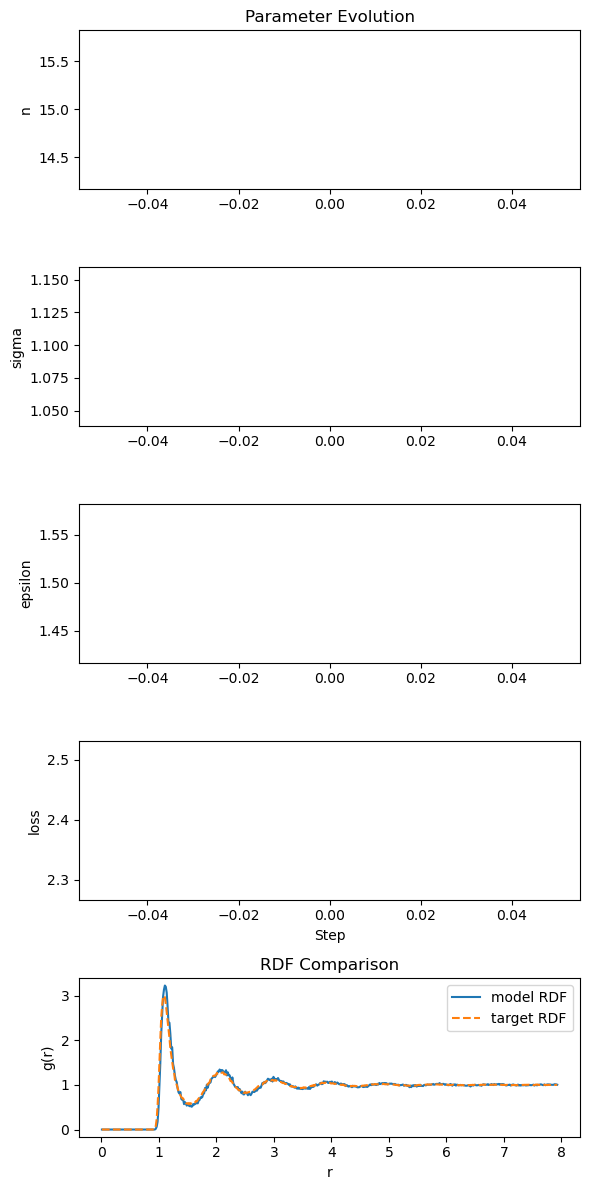

 10%|██████████▊                                                                                                 | 50/500 [02:17<20:43,  2.76s/it]

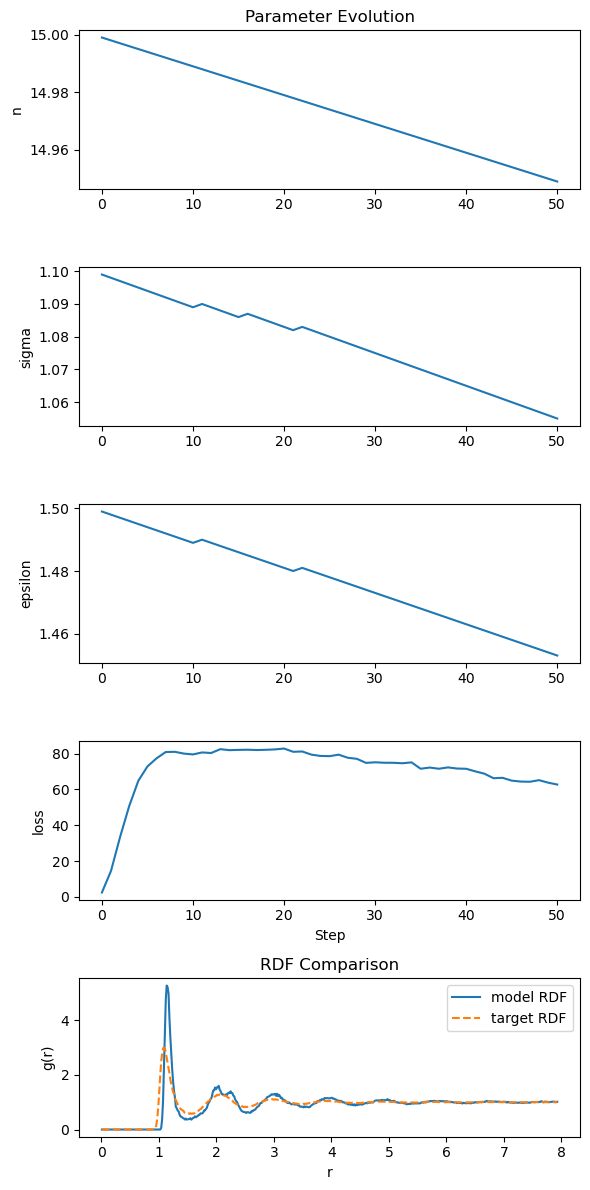

 13%|█████████████▊                                                                                              | 64/500 [02:58<20:14,  2.79s/it]


KeyboardInterrupt: 

In [18]:
for pppp in trange(500):
    optimizer = torch.optim.Adam([n, sigma, epsilon], lr=1e-3)

    for i in range(20):
        integrator.step(S)
    
        S.reset_cache()
        # shift all atoms back to the center 
        S.pos = (S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1))
        
    r,rdf = compute_rdf_from_conf(S.pos,S.box, torch.arange(N),torch.arange(N),smear=0.001,nbins=bins,exclude_diag=True)
    loss = torch.sum((rdf -target_rdf)**2)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    n =  torch.nn.Parameter(torch.tensor(n.detach().item())) 
    sigma = torch.nn.Parameter(torch.tensor(sigma.detach().item())) 
    epsilon = torch.nn.Parameter(torch.tensor(epsilon.detach().item()))
    
    param_history.append(torch.tensor([n.item(), sigma.item(), epsilon.item()]))
    loss_history.append(torch.tensor(loss.item()))
    
    mie = twobody.Mie(n = n, sigma = sigma, epsilon = epsilon, label = "mie")
    
    B = 1
    N = len(pos[0])
    pos = S.pos.detach()
    mom = 0.59*torch.randn(B,N,3,device=device)
    mass = torch.ones(N,device=device)
    mass = mass.unsqueeze(dim=0).expand(B,N)
    
    energy_dict = {"mie":mie}
    S = sys.System(pos, mom, mass, top, b, energy_dict, u)
    S.compile_force_fn()
    integrator = NVE(0.005)
    
    with torch.no_grad():
        for i in range(500):
            integrator.step(S)
        
            S.reset_cache()
            # shift all atoms back to the center 
            S.pos = (S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1))

    if pppp % 50 ==0:
        fig, axs = plt.subplots(5, 1, figsize=(6, 12), sharex=False)

        ph = torch.stack(param_history)
        
        axs[0].plot(ph[:, 0])
        axs[0].set_ylabel("n")
        axs[0].set_title("Parameter Evolution")
        
        axs[1].plot(ph[:, 1])
        axs[1].set_ylabel("sigma")
        
        axs[2].plot(ph[:, 2])
        axs[2].set_ylabel("epsilon")
        
        axs[3].plot(torch.stack(loss_history))
        axs[3].set_ylabel("loss")
        axs[3].set_xlabel("Step")
        
        axs[4].plot(r.detach().cpu(), rdf.detach().cpu(), label="model RDF")
        axs[4].plot(r.detach().cpu(), target_rdf.detach().cpu(), '--', label="target RDF")
        axs[4].set_ylabel("g(r)")
        axs[4].set_xlabel("r")
        axs[4].legend()
        axs[4].set_title("RDF Comparison")
        
        plt.tight_layout()
        plt.show()


In [ ]:
n =  torch.nn.Parameter(torch.tensor(15.0)) 
sigma = torch.nn.Parameter(torch.tensor(0.7)) 
epsilon = torch.nn.Parameter(torch.tensor(1.0)) 

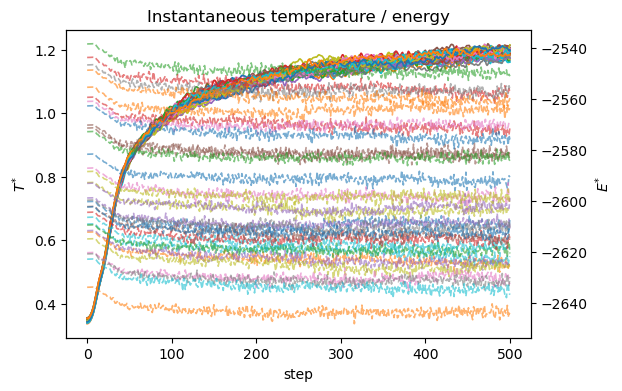

/users/1/sull1276/.conda/envs/spark/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Production:   0%|▎                                                                                             | 7/2000 [00:44<3:32:10,  6.39s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.04 GiB. GPU 0 has a total capacity of 44.34 GiB of which 298.81 MiB is free. Including non-PyTorch memory, this process has 44.04 GiB memory in use. Of the allocated memory 40.83 GiB is allocated by PyTorch, and 2.91 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [8]:
optimizer = torch.optim.Adam([n, sigma, epsilon], lr=1e-1)
param_history = [torch.tensor([n.item(), sigma.item(), epsilon.item()])]
update_params_stride = 100

# PRODUCTION
for i in trange(steps, desc="Production"):
    step_glob = i + eql_time
    temperature[step_glob] = S.temperature()
    total_energy[step_glob] = S.total_energy()

    with torch.no_grad():
        if step_glob % plot_skip == 0:
            _refresh_plot(step_glob)
            
    if i % update_params_stride == 0:
        integrator.step(S)
        r,rdf = compute_rdf_from_conf(S.pos,S.box, torch.arange(N),torch.arange(N),smear=0.001,nbins=bins,exclude_diag=True)
        loss = torch.sum((rdf -target_rdf**2))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        param_history.append(torch.tensor([n.item(), sigma.item(), epsilon.item()]))

        S.reset_cache()
        # shift all atoms back to the center 
        S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

    else:
        with torch.no_grad():
            integrator.step(S)
        
            S.reset_cafche()
            # shift all atoms back to the center 
            S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)
    
plt.ioff()                           
_refresh_plot(steps + eql_time - 1)  
plt.show()

In [ ]:
wikirdf = np.loadtxt("../LennardJonesFluid/wikipedia_rdf.csv", delimiter=",")

plt.title(
    fr"SPARK RDFs, $T^*={temperature.mean():.3f},\,n^*={len(pos[0])/b.volume:.3f}$"
)

for pidx, (t1, t2) in enumerate(pairs):
    qq = charge_dict[t1] * charge_dict[t2]
    g_r = rdfs[pidx].mean(dim=(0)).cpu()         # avg over time & replicas
    plt.plot(r.detach().cpu(), g_r, label=f"{t1}{t2} ($q_iq_j={qq}$)")

plt.scatter(*wikirdf.T, alpha=0.2,
            label=r"Wikipedia LJ, $T^{*}=0.71,n^{*}=0.844$")
plt.legend(fontsize=8, ncols=2)
plt.xlabel(r"$r/\sigma$")
plt.ylabel(r"$g_{ij}(r)$")
plt.show()

for j in range(0, B, 1):
    plt.plot(temperature[eql_time:, j].cpu(), label=f"T = {temperature[eql_time:, j].mean():.3f}")
plt.legend(ncol=2, fontsize=8)
plt.ylabel(r"$T^*$")
plt.show()

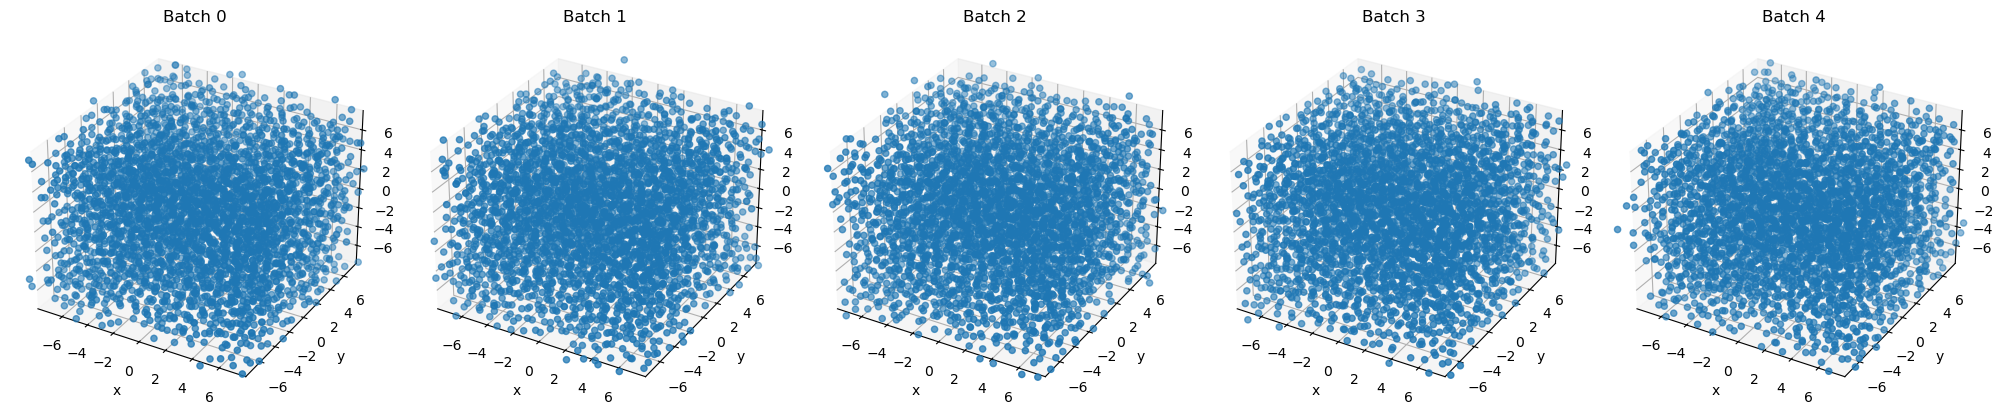

In [7]:
fig = plt.figure(figsize=(4 * pos.shape[0], 4))
for i in range(5):
    ax = fig.add_subplot(1, S.pos.shape[0], i + 1, projection='3d')
    ax.scatter(*S.pos[i].T.cpu().numpy())
    ax.set_title(f'Batch {i}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_xlim(-b.Lx.detach().cpu()/2,b.Lx.detach().cpu()/2)
    ax.set_ylim(-b.Ly.detach().cpu()/2,b.Ly.detach().cpu()/2)
    ax.set_zlim(-b.Lz.detach().cpu()/2,b.Lz.detach().cpu()/2)
plt.tight_layout()
plt.show()